# Chile Earthquake Magnitudes

Exploring the distribution of earthquake magnitudes in Chile using the relocated catalogue from the Centro Sismológico Nacional (CSN), 1982–mid-2020.

Potin et al. (2024), [doi:10.1785/0220240047](https://doi.org/10.1785/0220240047)


In [1]:
# Install empiricaldist if we don't already have it

try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

In [2]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download(
    "https://github.com/AllenDowney/ProbablyOverthinkingIt/raw/book/notebooks/utils.py"
)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from empiricaldist import Cdf, Surv
from utils import decorate, set_pyplot_params, make_surv, plot_error_bounds

set_pyplot_params()

## Load the catalogue

Data from [Potin et al. (2024)](https://doi.org/10.1785/0220240047): a revised, relocated Chilean seismic catalogue covering 1982 to mid-2020. See `chile/chilean_seismic_catalogue-1982-2020-publication_release/README.md` for column definitions and citation details.

In [4]:
DATA_DIR = "chile/chilean_seismic_catalogue-1982-2020-publication_release"
SEISMICITY_PATH = f"{DATA_DIR}/CHILE_SEISMICITY_RELOCATED.csv"

data = pd.read_csv(SEISMICITY_PATH)
data["magnitude_type"] = data["magnitude_type"].str.strip()
data.shape

(118004, 13)

In [5]:
data.head()

,#,year,month,day,hour,minute,seconds,longitude,latitude,depth,rms,magnitude,magnitude_type
0,0,1982,1,8,0,32,52.05,-71.760237,-32.218361,11.7341,0.95,NaN,xx
1,1,1982,1,9,1,6,18.81,-73.147276,-33.919849,5.3619,0.86,NaN,xx
2,2,1982,1,9,20,28,47.24,-70.053573,-32.952820,118.5877,0.27,NaN,xx
3,3,1982,1,12,15,4,33.20,-70.431024,-32.467427,89.8999,0.08,NaN,xx
4,4,1982,1,13,11,20,3.02,-69.627611,-31.559731,46.6019,1.49,NaN,xx


In [6]:
data.describe(include="all")

,#,year,month,day,hour,minute,seconds,longitude,latitude,depth,rms,magnitude,magnitude_type
count,118004.00000,118004.000000,118004.000000,118004.000000,118004.000000,118004.000000,118004.000000,118004.000000,118004.000000,118004.000000,118004.000000,109310.000000,118004
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,l
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89168
mean,59001.50000,2008.268915,6.537863,15.628521,11.320065,29.394961,30.028944,-70.540887,-29.325809,68.141672,0.357229,3.177608,NaN
std,34064.96492,9.381915,3.453024,8.782564,6.920552,17.304747,17.315109,1.531607,5.681583,56.104951,0.195222,0.792424,NaN
min,0.00000,1982.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-76.229448,-45.979579,-4.954000,0.010000,0.200000,NaN
25%,29500.75000,2003.000000,4.000000,8.000000,5.000000,14.000000,15.050000,-71.741079,-33.416475,22.039650,0.230000,2.700000,NaN
50%,59001.50000,2010.000000,6.000000,16.000000,11.000000,29.000000,30.070000,-70.707791,-31.664178,52.116300,0.310000,3.100000,NaN
75%,88502.25000,2016.000000,10.000000,23.000000,17.000000,44.000000,45.010000,-69.277223,-23.024681,105.557100,0.440000,3.600000,NaN


Magnitude is reported on several scales (`l` local, `c` coda, `w` and `ww` moment magnitude). Many early events have no magnitude estimate.

In [7]:
data["magnitude_type"].value_counts()

magnitude_type
l     89168
c     18629
xx     8694
ww     1238
W       265
B         9
          1
Name: count, dtype: int64

In [8]:
no_mag = data["magnitude"].isna() | (data["magnitude_type"] == "xx")
no_mag.mean()

0.0736754686281821

Keep events with a valid magnitude for the distribution analysis.

In [9]:
events = data.loc[~no_mag].copy()
events.groupby("magnitude_type")["magnitude"].describe()

,count,mean,std,min,25%,50%,75%,max
magnitude_type,,,,,,,,
,1.0,4.000000,NaN,4.0,4.0,4.0,4.0,4.0
B,9.0,4.811111,0.329562,4.4,4.6,4.8,5.1,5.3
W,265.0,5.167170,1.093272,2.1,4.7,5.2,5.8,8.8
c,18629.0,3.108449,1.172345,0.2,2.8,3.5,3.8,6.4
l,89168.0,3.163719,0.653422,0.6,2.7,3.1,3.5,6.8
ww,1238.0,4.780210,0.484259,3.1,4.5,4.7,5.0,7.6


The number of events per year has been increasing, which suggests better detection.

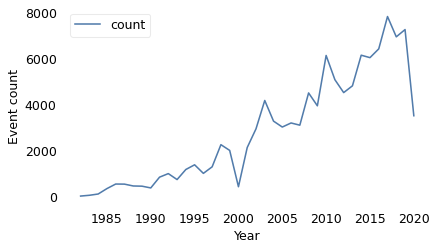

In [10]:
events["year"].value_counts().sort_index().plot()
decorate(xlabel="Year", ylabel="Event count")

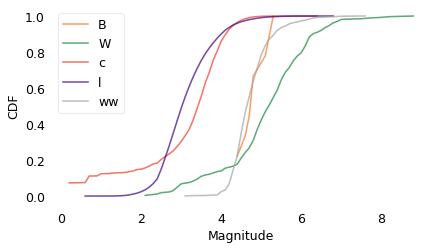

In [11]:
for mtype, group in events.groupby("magnitude_type"):
    Cdf.from_seq(group["magnitude"]).plot(label=mtype)

decorate(xlabel="Magnitude", ylabel="CDF")
plt.legend()
plt.savefig("chile_eda_cdf.png", dpi=300)

The distributions for the different kinds of magnitudes are substantially different.
I'm not sure it's valid to combine them, but for a first pass analysis, that's what I'm going to do.

In [12]:
mags = events["magnitude"]
mags.describe()

count    109310.000000
mean          3.177608
std           0.792424
min           0.200000
25%           2.700000
50%           3.100000
75%           3.600000
max           8.800000
Name: magnitude, dtype: float64

As expected, there are only a few very large magnitudes.

In [13]:
(mags >= 7).sum(), (mags >= 7.5).sum(), mags.max()

(11, 6, 8.8)

Here's the tail distribution (fraction of values >= x for all x).

In [14]:
surv = make_surv(mags)

In [15]:
xlabel = "Magnitude"
ylabel = "Prob >= $x$"

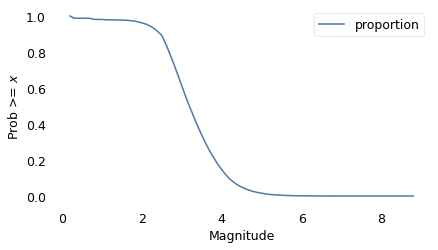

In [16]:
surv.plot()

decorate(xlabel=xlabel, ylabel=ylabel)

## Fit a Student t

Find the df parameter that best matches the tail, then the mu and sigma parameters that best match the percentiles.

In [17]:
from scipy.stats import t as t_dist


def truncated_t_sf(qs, df, mu, sigma):
    ps = t_dist.sf(qs, df, mu, sigma)
    surv_model = Surv(ps / ps[0], qs)
    return surv_model

In [18]:
from scipy.optimize import least_squares


def fit_truncated_t(df, surv):
    """Given df, find the best values of mu and sigma."""
    low, high = surv.qs.min(), surv.qs.max()
    qs_model = np.linspace(low, high, 1000)

    # match 20 percentiles from 10th to 99th
    ps = np.linspace(0.10, 0.9, 20)
    qs = surv.inverse(ps)

    def error_func_t(params, df, surv):
        mu, sigma = params
        surv_model = truncated_t_sf(qs_model, df, mu, sigma)

        error = surv(qs) - surv_model(qs)
        return error

    params = surv.mean(), surv.std()
    res = least_squares(error_func_t, x0=params, args=(df, surv), xtol=1e-3)
    assert res.success
    return res.x

In [19]:
from scipy.optimize import minimize


def minimize_df(df0, surv, bounds=[(1, 1e6)], ps=None):
    low, high = surv.qs.min(), surv.qs.max()
    qs_model = np.linspace(low, high * 1.0, 2000)

    if ps is None:
        t = surv.ps[0], surv.ps[-2]
        t = 0.1, surv.ps[-2]
        low, high = np.log10(t)
        ps = np.logspace(low, high, 30, endpoint=False)

    qs = surv.inverse(ps)

    def error_func_tail(params):
        (df,) = params
        mu, sigma = fit_truncated_t(df, surv)
        surv_model = truncated_t_sf(qs_model, df, mu, sigma)

        errors = np.log10(surv(qs)) - np.log10(surv_model(qs))
        return np.sum(errors**2)

    params = (df0,)
    res = minimize(error_func_tail, x0=params, bounds=bounds, tol=1e-3, method="Powell")
    assert res.success
    return res.x

Search for the value of df that best matches the tail behavior.

In [20]:
df = minimize_df(5, surv, [(1, 1000)])
df

array([8.92478953])

Given that value of df, find mu and sigma to best match percentiles.

In [21]:
mu, sigma = fit_truncated_t(df, surv)
df, mu, sigma

(array([8.92478953]), 3.209750270962042, 0.65453719080302)

Run the model out to magnitude 9.5

In [22]:
low, high = surv.qs.min(), 9.5
qs = np.linspace(low, high, 2000)
surv_model = truncated_t_sf(qs, df, mu, sigma)

On a linear scale:

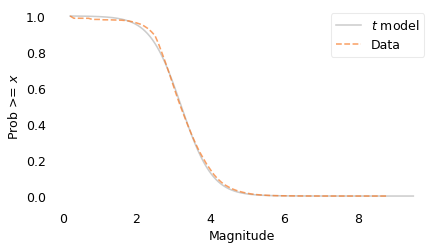

In [24]:
model_label = "$t$ model"

surv_model.plot(color="gray", alpha=0.4, label=model_label)
surv.plot(color="C1", ls="--", label="Data")

decorate(xlabel=xlabel, ylabel=ylabel)
plt.savefig("chile3.png", dpi=300)

The model fits the data well above magnitude 3.

Now on a log-y scale:

In [25]:
yticks = [1, 0.1, 0.01, 1e-3, 1e-4, 1e-5]
ylabels = yticks
xticks = np.arange(1, 10)
xlabels = xticks

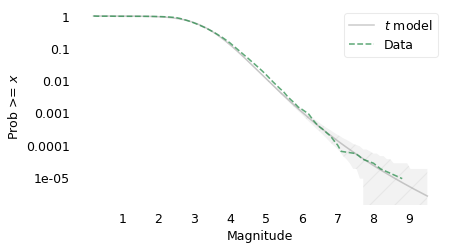

In [26]:
surv_model.plot(color="gray", alpha=0.4, label=model_label)
plot_error_bounds(Surv(surv_model), mags.count(), color="gray", hatch="/")
surv.plot(color="C2", ls="--", label="Data")

decorate(xlabel=xlabel, ylabel=ylabel, yscale="log")
plt.xticks(xticks, xlabels)
plt.yticks(yticks, ylabels)
plt.savefig("chile4.png", dpi=300)

And both together

In [27]:
def plot_two(surv, surv_model, n, hatch=None, title=""):
    """Plots tail distributions on linear-y and log-y scales.

    Uses global variables model_label, ylabel, xlabel, xticks, yticks, xlabels, ylabels.
    """
    fig, axs = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

    plt.sca(axs[0])
    surv_model.plot(color="gray", alpha=0.4, label=model_label)
    if n < 1000:
        plot_error_bounds(Surv(surv_model), n, color="gray")
    surv.plot(color="C1", ls="--", label="Data")
    decorate(ylabel=ylabel, title=title)

    plt.sca(axs[1])
    surv_model.plot(color="gray", alpha=0.4, label=model_label)
    plot_error_bounds(Surv(surv_model), n, color="gray", hatch=hatch)
    surv.plot(color="C2", ls="--", label="Data")
    decorate(xlabel=xlabel, ylabel=ylabel, yscale="log")
    plt.xticks(xticks, xlabels)
    plt.yticks(yticks, ylabels)

    plt.tight_layout()
    return axs

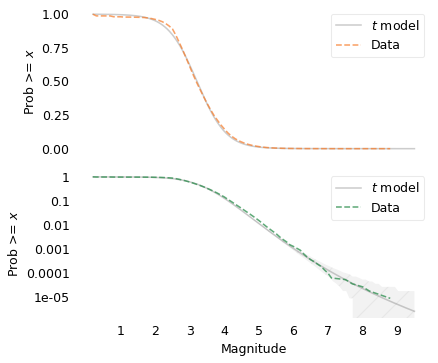

In [28]:
plot_two(surv, surv_model, mags.count(), hatch="/")
plt.savefig("chile_t_model.png", dpi=300)

The model fits the tail behavior well and makes plausible predictions for very large earthquakes.

Copyright 2026 Allen B. Downey

Example related to Chapter 9 from [Probably Overthinking It](https://allendowney.github.io/ProbablyOverthinkingIt/).

License: [Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/)